In [16]:
import pandas as pd
import numpy as np
import os
from itertools import product
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.feature_selection import mutual_info_classif
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sn
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix, accuracy_score, precision_recall_curve

In [2]:
# 1. Load dataset
df=pd.read_csv('../../dataset/diabetes_dataset.csv')
print("Initial data shape:", df.shape)
print(df.head());

Initial data shape: (100000, 16)
   year  gender   age location  race:AfricanAmerican  race:Asian  \
0  2020  Female  32.0  Alabama                     0           0   
1  2015  Female  29.0  Alabama                     0           1   
2  2015    Male  18.0  Alabama                     0           0   
3  2015    Male  41.0  Alabama                     0           0   
4  2016  Female  52.0  Alabama                     1           0   

   race:Caucasian  race:Hispanic  race:Other  hypertension  heart_disease  \
0               0              0           1             0              0   
1               0              0           0             0              0   
2               0              0           1             0              0   
3               1              0           0             0              0   
4               0              0           0             0              0   

  smoking_history    bmi  hbA1c_level  blood_glucose_level  diabetes  
0           never  27.32

In [3]:
# 2. Drop unneeded columns
df.drop(columns=[
    'year','location',
    'race:AfricanAmerican','race:Asian','race:Caucasian','race:Hispanic','race:Other','smoking_history'
], inplace=True)
print("After dropping columns:", df.shape)
print(df.head());

After dropping columns: (100000, 8)
   gender   age  hypertension  heart_disease    bmi  hbA1c_level  \
0  Female  32.0             0              0  27.32          5.0   
1  Female  29.0             0              0  19.95          5.0   
2    Male  18.0             0              0  23.76          4.8   
3    Male  41.0             0              0  27.32          4.0   
4  Female  52.0             0              0  23.75          6.5   

   blood_glucose_level  diabetes  
0                  100         0  
1                   90         0  
2                  160         0  
3                  159         0  
4                   90         0  


In [4]:
# 3. Encode gender
encoder = LabelEncoder()
df['gender'] = encoder.fit_transform(df['gender'])
print("Label Encoding Mapping:", dict(zip(encoder.classes_, range(len(encoder.classes_)))))

Label Encoding Mapping: {'Female': 0, 'Male': 1, 'Other': 2}


In [5]:
# 4. Drop duplicates & 'Other' gender
df.drop_duplicates(inplace=True)
df = df[df['gender'] != 2]
print("After dropping duplicates & 'Other':", df.shape)

After dropping duplicates & 'Other': (91295, 8)


In [6]:
## here we will perform the interaction
# Binary feature columns
from itertools import product
df['age_high'] = (df['age'] > 60).astype(int)
df['bmi_obese'] = (df['bmi'] > 23).astype(int)
df['hba1c_diabetes'] = (df['hbA1c_level'] > 6.5).astype(int)
df['glucose_high'] = (df['blood_glucose_level'] > 126).astype(int)

binary_cols = ['age_high', 'heart_disease', 'hba1c_diabetes', 'hypertension', 'bmi_obese', 'gender', 'glucose_high']

# Interaction for hbA1c_level with all others except hbA1c_level and blood_glucose_level
for col in binary_cols:
    if col not in ['hba1c_diabetes', 'glucose_high']:
        for val1, val2 in product([0, 1], repeat=2):
            new_col = f"hbA1c_level({val1}){col}({val2})"
            df[new_col] = ((df['hba1c_diabetes'] == val1) & (df[col] == val2)).astype(int)

df['hbA1c_level(0)_glucose_high(0)'] = ((df['glucose_high'] == 0) & (df['hba1c_diabetes'] == 0)).astype(int)
df['hbA1c_level(0)_glucose_high(1)'] = ((df['glucose_high'] == 0) & (df['hba1c_diabetes'] == 1)).astype(int)
df['hbA1c_level(1)_glucose_high(0)'] = ((df['glucose_high'] == 1) & (df['hba1c_diabetes'] == 0)).astype(int)
df['hbA1c_level(1)_glucose_high(1)'] = ((df['glucose_high'] == 1) & (df['hba1c_diabetes'] == 1)).astype(int)
# Interaction for blood_glucose_level with all others except hbA1c_level and blood_glucose_level
for col in binary_cols:
    if col not in ['hba1c_diabetes', 'glucose_high']:
        for val1, val2 in product([0, 1], repeat=2):
            new_col = f"glucose_high({val1}){col}({val2})"
            df[new_col] = ((df['glucose_high'] == val1) & (df[col] == val2)).astype(int)



df.drop(columns=['age_high','bmi_obese','hba1c_diabetes','glucose_high'],inplace=True)
df

,gender,age,hypertension,heart_disease,bmi,hbA1c_level,blood_glucose_level,diabetes,hbA1c_level(0)age_high(0),hbA1c_level(0)age_high(1),...,glucose_high(1)hypertension(0),glucose_high(1)hypertension(1),glucose_high(0)bmi_obese(0),glucose_high(0)bmi_obese(1),glucose_high(1)bmi_obese(0),glucose_high(1)bmi_obese(1),glucose_high(0)gender(0),glucose_high(0)gender(1),glucose_high(1)gender(0),glucose_high(1)gender(1)
0,0,32.0,0,0,27.32,5.0,100,0,1,0,...,0,0,0,1,0,0,1,0,0,0
1,0,29.0,0,0,19.95,5.0,90,0,1,0,...,0,0,1,0,0,0,1,0,0,0
2,1,18.0,0,0,23.76,4.8,160,0,1,0,...,1,0,0,0,0,1,0,0,0,1
3,1,41.0,0,0,27.32,4.0,159,0,1,0,...,1,0,0,0,0,1,0,0,0,1
4,0,52.0,0,0,23.75,6.5,90,0,1,0,...,0,0,0,1,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,0,33.0,0,0,21.21,6.5,90,0,1,0,...,0,0,1,0,0,0,1,0,0,0
99996,0,80.0,0,0,36.66,5.7,100,0,0,1,...,0,0,0,1,0,0,1,0,0,0
99997,1,46.0,0,0,36.12,6.2,158,0,1,0,...,1,0,0,0,0,1,0,0,0,1
99998,0,51.0,0,0,29.29,6.0,155,0,1,0,...,1,0,0,0,0,1,0,0,1,0


In [7]:
from sklearn.feature_selection import mutual_info_classif
# Filter only interaction columns
interaction_cols = [col for col in df.columns if col.startswith('glucose_high(') or col.startswith('hbA1c_level(')]
y = df['diabetes']
# Compute mutual information
mi_scores = mutual_info_classif(df[interaction_cols], y, discrete_features=True)
# len(mi_scores)
mi_series = pd.Series(mi_scores, index=interaction_cols).sort_values(ascending=False)
top_features = mi_series.head(10).index

print(top_features)

Index(['hbA1c_level(1)_glucose_high(1)', 'hbA1c_level(1)bmi_obese(1)',
       'hbA1c_level(0)heart_disease(0)', 'hbA1c_level(0)hypertension(0)',
       'hbA1c_level(0)age_high(0)', 'hbA1c_level(1)age_high(1)',
       'hbA1c_level(1)heart_disease(0)', 'glucose_high(1)age_high(1)',
       'glucose_high(1)bmi_obese(1)', 'hbA1c_level(1)hypertension(0)'],
      dtype='object')


In [8]:
df.drop(columns=[col for col in df.columns if col in interaction_cols and col not in top_features],inplace=True)
df

,gender,age,hypertension,heart_disease,bmi,hbA1c_level,blood_glucose_level,diabetes,hbA1c_level(0)age_high(0),hbA1c_level(1)age_high(1),hbA1c_level(0)heart_disease(0),hbA1c_level(1)heart_disease(0),hbA1c_level(0)hypertension(0),hbA1c_level(1)hypertension(0),hbA1c_level(1)bmi_obese(1),hbA1c_level(1)_glucose_high(1),glucose_high(1)age_high(1),glucose_high(1)bmi_obese(1)
0,0,32.0,0,0,27.32,5.0,100,0,1,0,1,0,1,0,0,0,0,0
1,0,29.0,0,0,19.95,5.0,90,0,1,0,1,0,1,0,0,0,0,0
2,1,18.0,0,0,23.76,4.8,160,0,1,0,1,0,1,0,0,0,0,1
3,1,41.0,0,0,27.32,4.0,159,0,1,0,1,0,1,0,0,0,0,1
4,0,52.0,0,0,23.75,6.5,90,0,1,0,1,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,0,33.0,0,0,21.21,6.5,90,0,1,0,1,0,1,0,0,0,0,0
99996,0,80.0,0,0,36.66,5.7,100,0,0,0,1,0,1,0,0,0,0,0
99997,1,46.0,0,0,36.12,6.2,158,0,1,0,1,0,1,0,0,0,0,1
99998,0,51.0,0,0,29.29,6.0,155,0,1,0,1,0,1,0,0,0,0,1


In [9]:
from imblearn.over_sampling import SMOTE
x=df.drop(columns=['diabetes'])
y=df['diabetes']
# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

In [10]:
# 12. Train KNN with k=13
knn = KNeighborsClassifier(n_neighbors=13, metric='manhattan', weights='distance')
knn.fit(X_train, y_train)

KNeighborsClassifier(metric='manhattan', n_neighbors=13, weights='distance')

In [11]:
# 13. Predict and evaluate
y_pred = knn.predict(X_test)

In [12]:
print("\n=== KNN WITH INTERACTIONS (k=13) ===")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


=== KNN WITH INTERACTIONS (k=13) ===
Accuracy: 0.9038282490826441
Precision: 0.4983351831298557
Recall: 0.7710360618202633
F1-score: 0.6053932584269663

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.92      0.95     16512
           1       0.50      0.77      0.61      1747

    accuracy                           0.90     18259
   macro avg       0.74      0.84      0.78     18259
weighted avg       0.93      0.90      0.91     18259

Confusion Matrix:
 [[15156  1356]
 [  400  1347]]


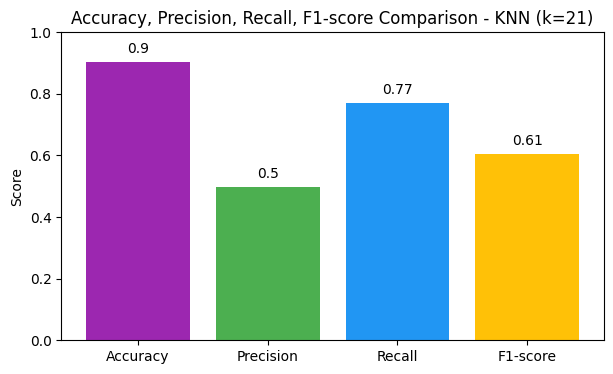

In [13]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score']
scores = [
    accuracy_score(y_test, y_pred),
    precision_score(y_test, y_pred),
    recall_score(y_test, y_pred),
    f1_score(y_test, y_pred)
]

plt.figure(figsize=(7,4))
bars = plt.bar(metrics, scores, color=['#9C27B0', '#4CAF50', '#2196F3', '#FFC107'])
plt.ylim([0, 1])
plt.title('Accuracy, Precision, Recall, F1-score Comparison - KNN (k=21)')
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, round(yval, 2), ha='center', va='bottom')
plt.ylabel('Score')
plt.show()

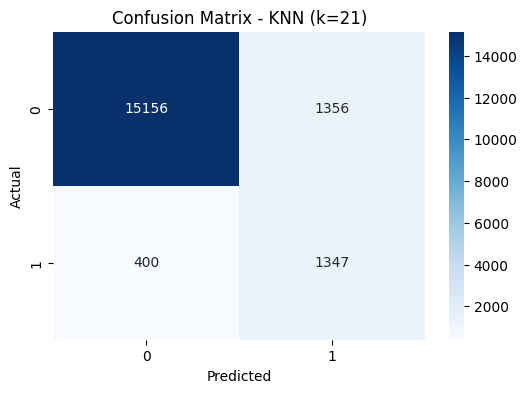

In [14]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sn.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - KNN (k=21)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

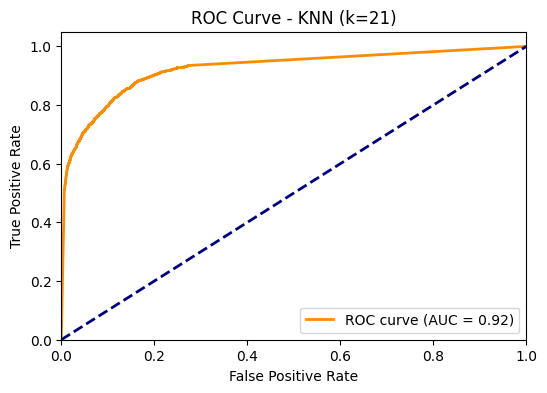

AUC: 0.9236192865787641


In [17]:

y_probs = knn.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (AUC = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - KNN (k=21)')
plt.legend(loc="lower right")
plt.show()

print("AUC:", roc_auc_score(y_test, knn.predict_proba(X_test)[:, 1]))